In [1]:
from pathlib import Path
import itertools
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler

ROOT = Path("/Users/mixednutgiftpack/Documents/CASA/OD2017_2023")
OUTPUTS = ROOT / "outputs"

In [2]:
df = pd.read_parquet(
    OUTPUTS / "destination_isolation_person_poi_2023.parquet"
)

daily = (
    pd.read_parquet(OUTPUTS / "isolation_person_day_2023.parquet")
    [["id_pess", "isolation"]]
    .drop_duplicates("id_pess")
    .rename(columns={"isolation": "I_allday"})
)

trips = pd.read_parquet(OUTPUTS / "trips_2023.parquet")

trip_mode = (
    trips[["id_pess", "n_viag", "modoprin"]]
    .dropna(subset=["modoprin"])
    .drop_duplicates(["id_pess", "n_viag"])
    .copy()
)

trip_mode["public_trip"] = trip_mode["modoprin"].between(1, 8)
trip_mode["private_car_trip"] = trip_mode["modoprin"].isin([9, 10])

person_mode = (
    trip_mode.groupby("id_pess", as_index=False)
    .agg(
        publict_per=("public_trip", "mean"),
        privatet_per=("private_car_trip", "mean")
    )
)

df = (
    df.drop(
        columns=[
            "I_allday",
            "publict_per",
            "privatet_per"
        ],
        errors="ignore"
    )
    .merge(
        daily,
        on="id_pess",
        how="inner",
        validate="one_to_one"
    )
    .merge(
        person_mode,
        on="id_pess",
        how="inner",
        validate="one_to_one"
    )
)

if "mobile" in df.columns:
    df = df.loc[df["mobile"].eq(True)].copy()

df = df.loc[df["I_allday"].gt(0)].copy()
df["y_allday"] = np.log2(df["I_allday"])

df["class6"] = df["class6"].replace({
    "D-E": "D–E",
    "D‑E": "D–E"
})

print("Analytical sample:", len(df))

Analytical sample: 35193


In [3]:
cats = [
    "food", "retail", "services", "auto", "industry",
    "health", "education", "religious", "leisure", "other"
]

df["age_group"] = pd.cut(
    df["idade"],
    bins=[17, 25, 59, np.inf],
    labels=["18–25", "26–59", "60+"]
)

if "race_group_model" not in df.columns:
    df["race_group_model"] = df["race_group"].where(
        df["race_group"].isin(["branca", "negra"]),
        "other"
    )

df[["gender", "race_group_model"]] = (
    df[["gender", "race_group_model"]]
    .replace({
        "None": np.nan,
        "nan": np.nan
    })
)

for c in cats:
    df[f"lph_{c}"] = np.log1p(
        df[f"ph_{c}"].fillna(0)
    )

destination_raw = [f"pdw_{c}" for c in cats]
df[destination_raw] = df[destination_raw].fillna(0)

df["pd_total"] = df[destination_raw].sum(axis=1) + 1

for c in cats:
    df[f"pd_{c}_prop"] = (
        df[f"pdw_{c}"] / df["pd_total"]
    )

df["log_pd_density"] = np.log(
    df["pd_total"] + 1
)

In [4]:
identity_specs = [
    ("gender", "who_gender", "F"),
    ("race_group_model", "who_race_group", "branca"),
    ("age_group", "who_age_group", "18–25"),
    ("cd_ativi", "who_cd_ativi", 1.0)
]

df = df.dropna(
    subset=[
        column for column, _, _ in identity_specs
    ]
).copy()

who_parts = []

for column, prefix, reference in identity_specs:
    levels = [reference] + sorted(
        [
            value for value in df[column].unique()
            if value != reference
        ],
        key=str
    )

    dummy = pd.get_dummies(
        pd.Categorical(
            df[column],
            categories=levels
        ),
        prefix=prefix,
        drop_first=True,
        dtype=float
    )

    dummy.index = df.index
    who_parts.append(dummy)

who = pd.concat(who_parts, axis=1)

df = pd.concat(
    [
        df.drop(columns=who.columns, errors="ignore"),
        who
    ],
    axis=1
)

variables = {
    "who": who.columns.tolist(),
    "home": [f"lph_{c}" for c in cats],
    "destination": [f"pd_{c}_prop" for c in cats],
    "density": ["log_pd_density"],
    "mobility": ["publict_per", "privatet_per"]
}

predictors = sum(variables.values(), [])

class_order = [
    "A", "B1", "B2", "C1", "C2", "D–E"
]

print({group: len(cols) for group, cols in variables.items()})
print(df.groupby("class6").size().reindex(class_order))

{'who': 12, 'home': 10, 'destination': 10, 'density': 1, 'mobility': 2}
class6
A       3676
B1      4211
B2     10074
C1      8697
C2      7048
D–E     1474
dtype: int64


In [5]:
def run_six_models(data, outcome):
    model_rows = []
    coefficient_rows = []
    fitted_models = {}

    for cls in class_order:
        columns = (
            predictors
            + [outcome, "fe_pess", "hex_home"]
        )

        d = (
            data.loc[data["class6"].eq(cls), columns]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        xvars = [
            variable for variable in predictors
            if d[variable].nunique() > 1
        ]

        X = pd.DataFrame(
            StandardScaler().fit_transform(d[xvars]),
            columns=xvars,
            index=d.index
        )

        y = StandardScaler().fit_transform(
            d[[outcome]]
        ).ravel()

        fit = sm.WLS(
            y,
            sm.add_constant(X, has_constant="add"),
            weights=d["fe_pess"]
        ).fit(
            cov_type="cluster",
            cov_kwds={"groups": d["hex_home"]}
        )

        fitted_models[cls] = fit
        confidence = fit.conf_int()

        model_rows.append({
            "class6": cls,
            "n": len(d),
            "r2": fit.rsquared,
            "significant": int(
                (fit.pvalues.drop("const") < 0.05).sum()
            )
        })

        for variable in xvars:
            coefficient_rows.append({
                "class6": cls,
                "group": next(
                    group
                    for group, columns in variables.items()
                    if variable in columns
                ),
                "variable": variable,
                "coef": fit.params[variable],
                "lower": confidence.loc[variable, 0],
                "upper": confidence.loc[variable, 1],
                "p": fit.pvalues[variable]
            })

    return (
        pd.DataFrame(model_rows),
        pd.DataFrame(coefficient_rows),
        fitted_models
    )

In [6]:
def run_lmg(data, outcome):
    groups = list(variables)
    rows = []

    for cls in class_order:
        columns = (
            predictors
            + [outcome, "fe_pess"]
        )

        d = (
            data.loc[data["class6"].eq(cls), columns]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        r2_cache = {frozenset(): 0.0}

        for size in range(1, len(groups) + 1):
            for subset in itertools.combinations(groups, size):
                xvars = sum(
                    [variables[group] for group in subset],
                    []
                )

                xvars = [
                    variable for variable in xvars
                    if d[variable].nunique() > 1
                ]

                if xvars:
                    fit = sm.WLS(
                        d[outcome],
                        sm.add_constant(
                            d[xvars],
                            has_constant="add"
                        ),
                        weights=d["fe_pess"]
                    ).fit()

                    r2_cache[frozenset(subset)] = fit.rsquared
                else:
                    r2_cache[frozenset(subset)] = 0.0
            previous = 0.0

            for group in order:
                used = used | {group}
                current = r2_cache[used]

                contribution[group] += max(
                    current - previous,
                    0.0
                )

                previous = current

        contribution = {
            group: contribution[group] / len(orders)
            for group in groups
        }

        total = sum(contribution.values())

        rows.append({
            "class6": cls,
            **{
                group: 100 * contribution[group] / total
                for group in groups
            }
        })

    return pd.DataFrame(rows)

In [7]:
def run_lmg(data, outcome):
    groups = list(variables)
    rows = []

    for cls in class_order:
        columns = predictors + [outcome, "fe_pess"]

        d = (
            data.loc[data["class6"].eq(cls), columns]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        r2_cache = {frozenset(): 0.0}

        for size in range(1, len(groups) + 1):
            for subset in itertools.combinations(groups, size):
                xvars = sum(
                    [variables[group] for group in subset],
                    []
                )

                xvars = [
                    variable for variable in xvars
                    if d[variable].nunique() > 1
                ]

                if xvars:
                    fit = sm.WLS(
                        d[outcome],
                        sm.add_constant(
                            d[xvars],
                            has_constant="add"
                        ),
                        weights=d["fe_pess"]
                    ).fit()

                    r2_cache[frozenset(subset)] = fit.rsquared

                else:
                    r2_cache[frozenset(subset)] = 0.0

        contribution = dict.fromkeys(groups, 0.0)
        orders = list(itertools.permutations(groups))

        for order in orders:
            used = frozenset()
            previous = 0.0

            for group in order:
                used = used | {group}
                current = r2_cache[used]

                contribution[group] += max(
                    current - previous,
                    0.0
                )

                previous = current

        contribution = {
            group: contribution[group] / len(orders)
            for group in groups
        }

        total = sum(contribution.values())

        rows.append({
            "class6": cls,
            **{
                group: 100 * contribution[group] / total
                for group in groups
            }
        })

    return pd.DataFrame(rows)

In [8]:
model_summary, coefficients, models = run_six_models(
    df,
    "y_allday"
)

lmg = run_lmg(
    df,
    "y_allday"
)

display(model_summary.round(3))
display(lmg.round(2))

,class6,n,r2,significant
0,A,3676,0.320,8
1,B1,4211,0.157,2
2,B2,10074,0.136,6
3,C1,8697,0.041,3
4,C2,7048,0.152,12
5,D–E,1474,0.133,7


,class6,who,home,destination,density,mobility
0,A,6.48,56.95,30.66,4.70,1.22
1,B1,9.30,50.63,37.58,0.99,1.50
2,B2,13.61,60.00,25.48,0.38,0.53
3,C1,8.34,51.78,34.86,1.35,3.67
4,C2,8.47,52.23,36.74,1.18,1.38
5,D–E,28.51,34.83,30.68,1.23,4.76


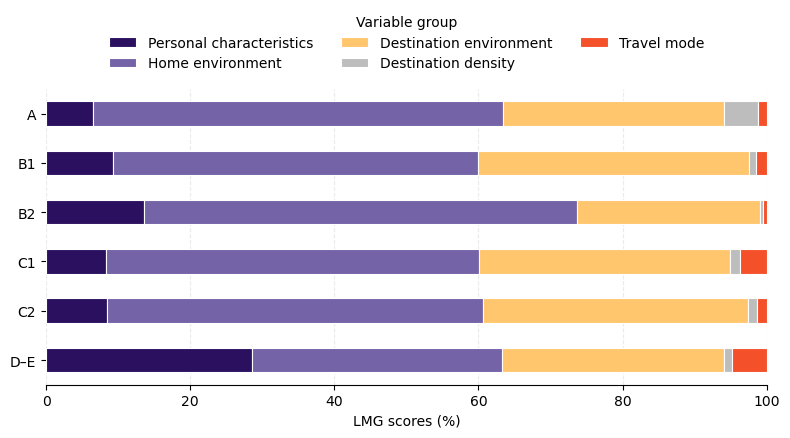

In [9]:
groups = [
    "who",
    "home",
    "destination",
    "density",
    "mobility"
]

labels = {
    "who": "Personal characteristics",
    "home": "Home environment",
    "destination": "Destination environment",
    "density": "Destination density",
    "mobility": "Travel mode"
}

colors = {
    "who": "#2B105F",
    "home": "#7563A8",
    "destination": "#FFC66D",
    "density": "#BDBDBD",
    "mobility": "#F4512A" 
}

plot_df = (
    lmg.set_index("class6")
    .reindex(class_order)[groups]
    .rename(columns=labels)
)

fig, ax = plt.subplots(figsize=(8, 4.5))

plot_df.plot(
    kind="barh",
    stacked=True,
    color=[colors[group] for group in groups],
    edgecolor="white",
    linewidth=0.8,
    ax=ax
)

ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("LMG scores (%)")
ax.set_ylabel("")
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)

ax.legend(
    title="Variable group",
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False
)

plt.tight_layout()

fig.savefig(
    OUTPUTS / "rq3_allday_lmg_by_class_2023.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

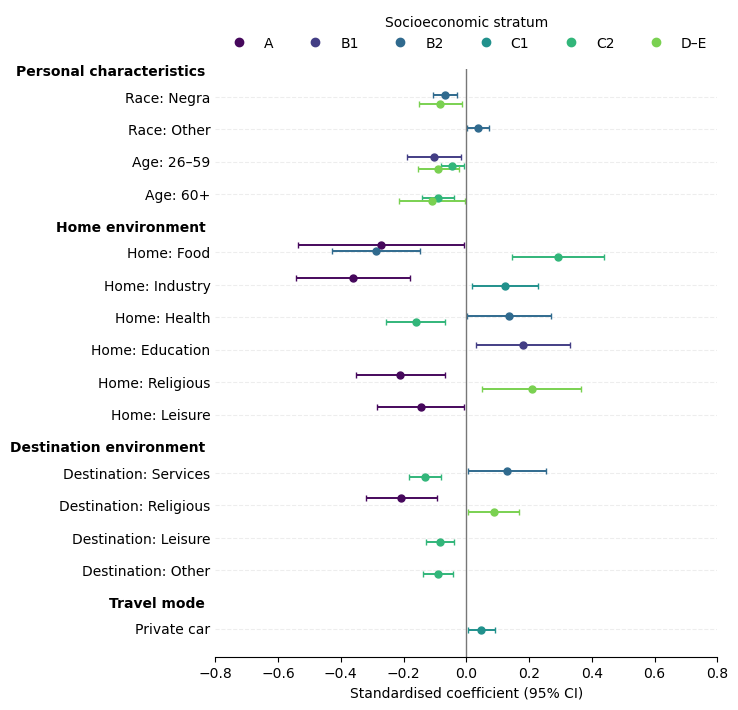

In [10]:
classes = [
    "A", "B1", "B2", "C1", "C2", "D–E"
]

colors = {
    "A": "#46085C",
    "B1": "#433E85",
    "B2": "#306A8E",
    "C1": "#21918C",
    "C2": "#32B67A",
    "D–E": "#7AD151"
}

coefs = coefficients.copy()

coefs = coefs[
    ~coefs["variable"].str.startswith("who_cd_ativi_")
    & coefs["p"].lt(0.05)
].copy()

groups = [
    "who",
    "home",
    "destination",
    "mobility"
]

group_labels = {
    "who": "Personal characteristics",
    "home": "Home environment",
    "destination": "Destination environment",
    "mobility": "Travel mode"
}

var_order = [
    variable
    for group in groups
    for variable in variables[group]
    if variable in coefs["variable"].unique()
    and not variable.startswith("who_cd_ativi_")
]

def clean_label(variable):
    names = {
        "publict_per": "Collective transport",
        "privatet_per": "Private car"
    }

    return names.get(
        variable,
        variable
        .replace("who_gender_", "Gender: ")
        .replace("who_race_group_", "Race: ")
        .replace("who_age_group_", "Age: ")
        .replace("lph_", "Home: ")
        .replace("pd_", "Destination: ")
        .replace("_prop", "")
        .replace("_", " ")
        .title()
    )

ypos = {}
starts = {}
y = 0

for group in groups:
    group_vars = [
        variable for variable in var_order
        if variable in variables[group]
    ]

    if not group_vars:
        continue

    starts[group] = y

    for variable in group_vars:
        ypos[variable] = y
        y += 1

    y += 0.8

offsets = dict(
    zip(classes, np.linspace(-0.22, 0.22, 6))
)

fig, ax = plt.subplots(
    figsize=(7.5, max(4.5, len(var_order) * 0.48))
)

for cls in classes:
    d = coefs[
        coefs["class6"].eq(cls)
        & coefs["variable"].isin(var_order)
    ]

    if d.empty:
        continue

    yy = [
        ypos[variable] + offsets[cls]
        for variable in d["variable"]
    ]

    ax.errorbar(
        d["coef"],
        yy,
        xerr=[
            d["coef"] - d["lower"],
            d["upper"] - d["coef"]
        ],
        fmt="o",
        color=colors[cls],
        markersize=5,
        linewidth=1.4,
        capsize=2
    )

ax.axvline(
    0,
    color="#777777",
    linewidth=1
)

ax.set_yticks([
    ypos[variable] for variable in var_order
])

ax.set_yticklabels([
    clean_label(variable) for variable in var_order
])

ax.tick_params(axis="y", length=0)
ax.invert_yaxis()

for group, start in starts.items():
    ax.text(
        -0.02,
        start - 0.55,
        group_labels[group],
        transform=ax.get_yaxis_transform(),
        ha="right",
        va="bottom",
        fontweight="bold"
    )

ax.set_xlabel("Standardised coefficient (95% CI)")
ax.set_ylabel("")
ax.grid(axis="y", linestyle="--", alpha=0.22)
ax.spines[["top", "right", "left"]].set_visible(False)

legend = [
    Line2D(
        [0],
        [0],
        marker="o",
        color=colors[cls],
        linestyle="none",
        label=cls
    )
    for cls in classes
]

ax.legend(
    handles=legend,
    title="Socioeconomic stratum",
    ncol=6,
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01)
)

ax.set_xlim(-0.8, 0.8)
ax.set_xticks(np.arange(-0.8, 0.81, 0.2))

plt.tight_layout()

fig.savefig(
    OUTPUTS / "rq3_allday_significant_coefficients_2023.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

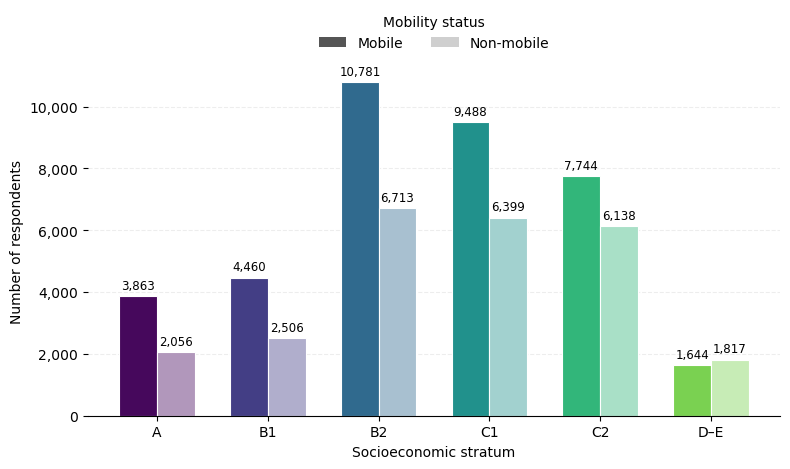

Saved: /Users/mixednutgiftpack/Documents/CASA/OD2017_2023/outputs/rq3_mobile_nonmobile_sample_size_2023.png


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import to_rgb
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

class_order = ["A", "B1", "B2", "C1", "C2", "D–E"]

class_colors = {
    "A": "#46085C",
    "B1": "#433E85",
    "B2": "#306A8E",
    "C1": "#21918C",
    "C2": "#32B67A",
    "D–E": "#7AD151"
}

# Load and prepare
persons = (
    pd.read_parquet(OUTPUTS / "persons_2023.parquet")
      [["id_pess", "class6", "mobile", "idade", "fe_pess"]]
      .drop_duplicates("id_pess")
)

daily = (
    pd.read_parquet(OUTPUTS / "isolation_person_day_2023.parquet")
      [["id_pess", "isolation"]]
      .drop_duplicates("id_pess")
)

compare = persons.merge(
    daily,
    on="id_pess",
    how="inner",
    validate="one_to_one"
)

compare["class6"] = compare["class6"].replace({
    "D-E": "D–E",
    "D‑E": "D–E"
})

compare = compare.loc[
    compare["idade"].ge(18)
    & compare["isolation"].gt(0)
    & compare["fe_pess"].gt(0)
].copy()

compare["mobility"] = np.where(
    compare["mobile"].eq(True),
    "Mobile",
    "Non-mobile"
)

summary = (
    compare.groupby(
        ["class6", "mobility"],
        observed=True
    )
    .size()
    .rename("n")
    .reset_index()
)

n_table = (
    summary.pivot(
        index="class6",
        columns="mobility",
        values="n"
    )
    .reindex(class_order)
    .fillna(0)
)

def lighten(color, amount=0.58):
    rgb = np.array(to_rgb(color))
    return tuple(rgb + (1 - rgb) * amount)

x = np.arange(len(class_order))
width = 0.34

dark_colors = [class_colors[c] for c in class_order]
light_colors = [lighten(class_colors[c]) for c in class_order]

fig, ax = plt.subplots(figsize=(8, 4.8))

mobile_bars = ax.bar(
    x - width / 2,
    n_table["Mobile"],
    width,
    color=dark_colors,
    edgecolor="white",
    linewidth=0.8
)

nonmobile_bars = ax.bar(
    x + width / 2,
    n_table["Non-mobile"],
    width,
    color=light_colors,
    edgecolor="white",
    linewidth=0.8
)

for bars in [mobile_bars, nonmobile_bars]:
    ax.bar_label(
        bars,
        labels=[f"{int(bar.get_height()):,}" for bar in bars],
        padding=3,
        fontsize=8.5
    )

ax.set(
    xticks=x,
    xticklabels=class_order,
    xlabel="Socioeconomic stratum",
    ylabel="Number of respondents"
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"{int(value):,}")
)

ax.grid(axis="y", linestyle="--", alpha=0.22)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)

ax.legend(
    handles=[
        Patch(facecolor="#555555", label="Mobile"),
        Patch(facecolor="#CFCFCF", label="Non-mobile")
    ],
    title="Mobility status",
    frameon=False,
    ncol=2,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01)
)

plt.tight_layout()

figure_path = OUTPUTS / "rq3_mobile_nonmobile_sample_size_2023.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
print(f"Saved: {figure_path}")